
ARIMA Model Evaluation:
Mean Absolute Error (MAE): 28.8116
Mean Squared Error (MSE): 4179.0233
Root Mean Squared Error (RMSE): 64.6454
R² Score: 0.7538
MAPE: 18.39%
Estimated Accuracy: 81.61%


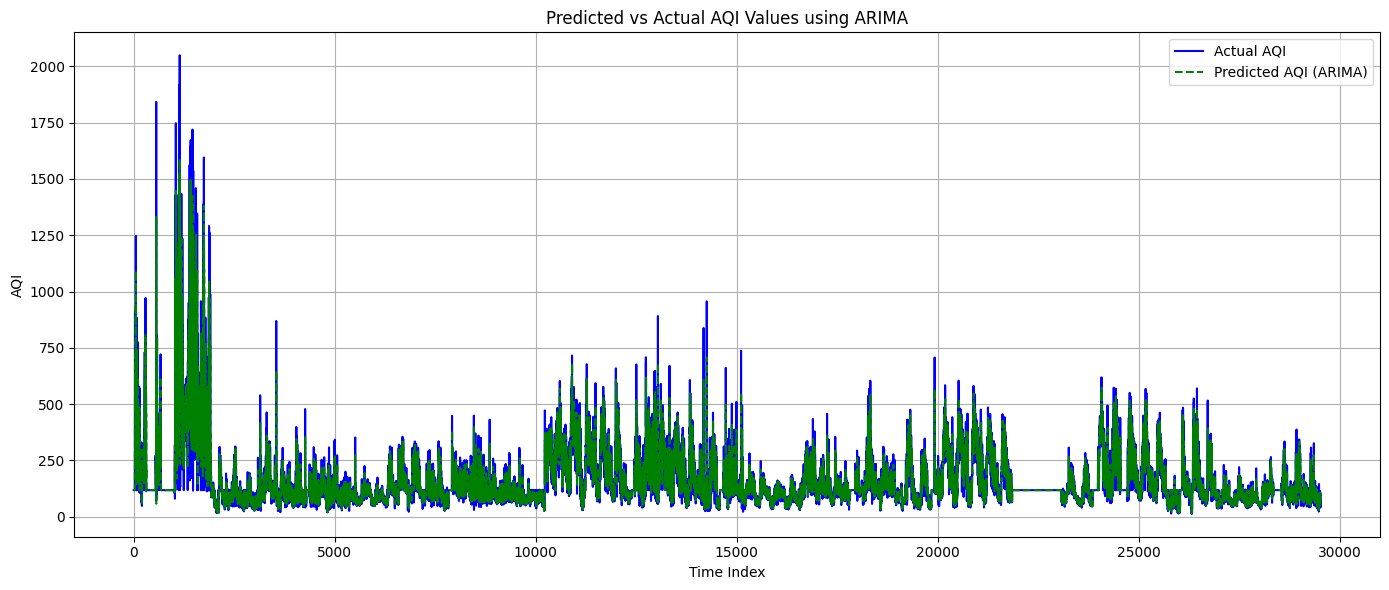

In [2]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load your AQI dataset
df = pd.read_csv("./AirQuality_Cleaned.csv")  # Adjust path if needed

# Step 1: Prepare AQI data
aqi_values = df['AQI'].values.reshape(-1, 1)
scaler = MinMaxScaler()
aqi_scaled = scaler.fit_transform(aqi_values).flatten()

# Step 2: Fit ARIMA model
# You can experiment with different (p,d,q) values based on AIC/BIC or autocorrelation plots
arima_model = ARIMA(aqi_scaled, order=(5, 1, 0))  # Example order, can be tuned
arima_result = arima_model.fit()

# Step 3: Forecast
start = 1
end = len(aqi_scaled) - 1
arima_forecast_scaled = arima_result.predict(start=start, end=end)

# Step 4: Inverse transform predictions
arima_forecast_scaled = np.array(arima_forecast_scaled).reshape(-1, 1)
arima_forecast = scaler.inverse_transform(arima_forecast_scaled)

# Step 5: Evaluation
true_values = scaler.inverse_transform(aqi_scaled[start:].reshape(-1, 1))

mae = mean_absolute_error(true_values, arima_forecast)
mse = mean_squared_error(true_values, arima_forecast)
rmse = np.sqrt(mse)
r2 = r2_score(true_values, arima_forecast)
mape = np.mean(np.abs((true_values - arima_forecast) / true_values)) * 100
accuracy = 100 - mape

print("\nARIMA Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Estimated Accuracy: {accuracy:.2f}%")

# Step 6: Plotting Predicted vs Actual AQI Values
plt.figure(figsize=(14, 6))
plt.plot(true_values, label='Actual AQI', color='blue')
plt.plot(arima_forecast, label='Predicted AQI (ARIMA)', color='green', linestyle='--')
plt.title('Predicted vs Actual AQI Values using ARIMA')
plt.xlabel('Time Index')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
